# SMART 2018 exploratory data analysis

This notebook analyzes `S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SMART_2018`
through the Snowflake Spark connector.

**Execution contract**

- Selected-variable statistics, selected-pair covariance, null-pattern grouping,
  and disk/model aggregation execute in the configured Snowflake warehouse.
- Spark receives only aggregate result tables or plot-ready histogram bins.
- Pairwise covariance is exact by default; only the bounded relationship graph
  uses a reproducible Snowflake-side sample.
- Never replace these aggregate queries with `toPandas()` on the source table.


## 0. Runtime, imports, and analysis configuration

In [56]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark
import seaborn as sns

from snowflake_io import create_spark_session, read_snowflake_query

print("Python:", sys.executable)
print("PySpark:", pyspark.__version__)
print("Spark home:", os.environ.get("SPARK_HOME"))

spark = create_spark_session("smart-2018-cloud-eda")
spark.conf.set("spark.sql.debug.maxToStringFields", 250)

SMART_TABLE = "S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SMART_2018"
SMART_SCHEMA = "S_CDATOS_PSET2_SILVER"

ATTRIBUTE_IDS = [
    *range(1, 14),
    170, 171, 172, 173, 174, 177, 180, 181, 182, 183, 184,
    187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197,
    198, 199, 200, 204, 205, 206, 207, 211, 233, 240, 241,
    242, 244, 245, 175, 232,
]
SMART_COLUMNS = [
    f"{prefix}_{attribute_id}"
    for attribute_id in ATTRIBUTE_IDS
    for prefix in ("R", "N")
]
ANALYSIS_COLUMNS = ["DISK_ID", "MODEL_CODE", *SMART_COLUMNS]
VARIABLE_MENU = pd.DataFrame({
    "NUMBER": range(1, len(SMART_COLUMNS) + 1),
    "VARIABLE": SMART_COLUMNS,
})

HISTOGRAM_BINS = 40
INTERACTION_SAMPLE_PERCENT = 100.0
INTERACTION_PLOT_SAMPLE_PERCENT = 0.05
INTERACTION_PLOT_ROW_LIMIT = 10_000

# Detailed null signatures are ranked and capped only for notebook display.
# The summary by number of null columns remains exact and uncapped.
NULL_PATTERN_DISPLAY_LIMIT = 10_000
ANALYSIS_YEAR = int(SMART_TABLE.rsplit("_", 1)[1])
COMPARISON_YEAR = 4037 - ANALYSIS_YEAR
COMPARISON_SMART_TABLE = (
    f"S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SMART_{COMPARISON_YEAR}"
)
FAILURE_LABEL_TABLE = "S_CDATOS_PSET2.S_CDATOS_PSET2_SILVER.SSD_FAILURE_LABELS"
MODEL_PATTERN_TOP_N = 10
MC1_PATTERN_DISPLAY_LIMIT = 100
PATTERN_COVERAGE_THRESHOLD = 90.0
FAILURE_WINDOW_DAYS = 30
FAILURE_RATE_DIFFERENCE_THRESHOLD = 2.0  # percentage points
DUPLICATE_DETAIL_LIMIT = 10_000
EXPORT_DIR = Path("/opt/spark/notebooks/exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 500)


Python: /usr/bin/python3
PySpark: 4.0.4
Spark home: /opt/spark


In [57]:
def quote_identifier(value: str) -> str:
    if value not in ANALYSIS_COLUMNS and value not in SMART_COLUMNS:
        raise ValueError(f"Unrecognized analysis column: {value}")
    return '"' + value.replace('"', '""') + '"'


def qualified_identifier(value: str, alias: str) -> str:
    return f"{alias}.{quote_identifier(value)}"


def null_pattern_array_sql(alias: str, columns: list[str] = SMART_COLUMNS) -> str:
    items = [
        f"IFF({qualified_identifier(column, alias)} IS NULL, '{column}', NULL)"
        for column in columns
    ]
    return "ARRAY_CONSTRUCT_COMPACT(" + ", ".join(items) + ")"


def snowflake_query(query: str):
    return read_snowflake_query(spark, query, schema=SMART_SCHEMA)


def aggregate_to_pandas(query: str) -> pd.DataFrame:
    # Only use this helper for intentionally compact aggregate results.
    return snowflake_query(query).toPandas()


def show_variable_menu() -> None:
    display(VARIABLE_MENU)


def select_variable(prompt: str, *, excluded: set[str] | None = None) -> str:
    excluded = excluded or set()
    while True:
        raw_value = input(f"{prompt} [1-{len(SMART_COLUMNS)}]: ").strip()
        try:
            number = int(raw_value)
        except ValueError:
            print("Enter an integer from the NUMBER column.")
            continue
        if not 1 <= number <= len(SMART_COLUMNS):
            print(f"Enter a number between 1 and {len(SMART_COLUMNS)}.")
            continue
        variable = SMART_COLUMNS[number - 1]
        if variable in excluded:
            print(f"{variable} is already selected; choose a different variable.")
            continue
        print(f"Selected {number} -> {variable}")
        return variable


_univariate_stats_cache: dict[str, pd.DataFrame] = {}


def univariate_statistics(column: str) -> pd.DataFrame:
    if column in _univariate_stats_cache:
        return _univariate_stats_cache[column]
    identifier = quote_identifier(column)
    result = aggregate_to_pandas(f'''
        SELECT
            '{column}' AS VARIABLE,
            COUNT(*) AS TOTAL_ROWS,
            COUNT({identifier}) AS NON_NULL_ROWS,
            COUNT_IF({identifier} IS NULL) AS NULL_ROWS,
            ROUND(100 * COUNT_IF({identifier} IS NULL) / NULLIF(COUNT(*), 0), 6) AS NULL_PERCENT,
            MIN({identifier}) AS MINIMUM,
            APPROX_PERCENTILE({identifier}, 0.25) AS Q1,
            AVG({identifier}) AS MEAN,
            APPROX_PERCENTILE({identifier}, 0.50) AS MEDIAN,
            APPROX_PERCENTILE({identifier}, 0.75) AS Q3,
            MAX({identifier}) AS MAXIMUM,
            STDDEV_SAMP({identifier}) AS STANDARD_DEVIATION,
            VAR_SAMP({identifier}) AS SAMPLE_VARIANCE
        FROM {SMART_TABLE}
    ''')
    _univariate_stats_cache[column] = result
    return result


def plot_box_summary(column: str) -> None:
    row = univariate_statistics(column).iloc[0]
    if int(row["NON_NULL_ROWS"]) == 0:
        print(f"{column} contains no non-null values.")
        return
    summary = [{
        "label": column,
        "whislo": float(row["MINIMUM"]),
        "q1": float(row["Q1"]),
        "med": float(row["MEDIAN"]),
        "q3": float(row["Q3"]),
        "whishi": float(row["MAXIMUM"]),
        "fliers": [],
    }]
    _, axis = plt.subplots(figsize=(9, 2.8))
    axis.bxp(summary, vert=False, showfliers=False)
    axis.set_title(f"{column}: quartiles with minimum/maximum whiskers")
    axis.set_xlabel(column)
    plt.tight_layout()
    plt.show()


def histogram_bins(column: str, bins: int = HISTOGRAM_BINS) -> pd.DataFrame:
    row = univariate_statistics(column).iloc[0]
    if int(row["NON_NULL_ROWS"]) == 0:
        return pd.DataFrame(columns=["BUCKET", "BIN_MIN", "BIN_MAX", "ROW_COUNT"])
    minimum = float(row["MINIMUM"])
    maximum = float(row["MAXIMUM"])
    identifier = quote_identifier(column)
    if minimum == maximum:
        return pd.DataFrame({
            "BUCKET": [1], "BIN_MIN": [minimum], "BIN_MAX": [maximum],
            "ROW_COUNT": [int(row["NON_NULL_ROWS"])],
        })
    return aggregate_to_pandas(f'''
        SELECT
            LEAST({bins}, WIDTH_BUCKET({identifier}, {minimum}, {maximum}, {bins})) AS BUCKET,
            MIN({identifier}) AS BIN_MIN,
            MAX({identifier}) AS BIN_MAX,
            COUNT(*) AS ROW_COUNT
        FROM {SMART_TABLE}
        WHERE {identifier} IS NOT NULL
        GROUP BY 1
        ORDER BY 1
    ''')


def plot_histogram(column: str) -> None:
    histogram = histogram_bins(column)
    if histogram.empty:
        print(f"{column} contains no non-null values.")
        return
    centers = (histogram["BIN_MIN"].astype(float) + histogram["BIN_MAX"].astype(float)) / 2
    widths = (histogram["BIN_MAX"].astype(float) - histogram["BIN_MIN"].astype(float)).replace(0, 1)
    _, axis = plt.subplots(figsize=(10, 4))
    axis.bar(centers, histogram["ROW_COUNT"].astype(float), width=widths, align="center")
    axis.set_title(f"{column}: Snowflake-aggregated histogram")
    axis.set_xlabel(column)
    axis.set_ylabel("Record count")
    plt.tight_layout()
    plt.show()


## 1. Menu-driven univariate distribution

Run the menu cell, enter the number shown beside a SMART variable, and then run
the three analysis cells. Menu item `1` maps to `R_1`. Only the selected
variable is submitted to Snowflake.


In [ ]:
show_variable_menu()
selected_univariate_column = select_variable("Select the univariate variable")


In [ ]:
# Selected variable — one statistical summary table
display(univariate_statistics(selected_univariate_column))


In [ ]:
# Selected variable — box summary
plot_box_summary(selected_univariate_column)


In [ ]:
# Selected variable — histogram
plot_histogram(selected_univariate_column)


## 2. Interaction between two selected variables

Choose two different menu numbers. Snowflake calculates their covariance,
correlation, regression slope, and regression intercept. The relationship plot
downloads at most `INTERACTION_PLOT_ROW_LIMIT` non-null sampled pairs; it never
downloads the full SMART table.


In [ ]:
show_variable_menu()
selected_interaction_a = select_variable("Select the first interaction variable")
selected_interaction_b = select_variable(
    "Select the second interaction variable",
    excluded={selected_interaction_a},
)


In [ ]:
def pairwise_interaction(
    variable_a: str,
    variable_b: str,
    sample_percent: float = INTERACTION_SAMPLE_PERCENT,
) -> pd.DataFrame:
    if not 0 < sample_percent <= 100:
        raise ValueError("sample_percent must be in (0, 100]")
    identifier_a = quote_identifier(variable_a)
    identifier_b = quote_identifier(variable_b)
    sampled_relation = (
        SMART_TABLE
        if sample_percent == 100
        else f"{SMART_TABLE} SAMPLE BERNOULLI ({sample_percent}) SEED (2018)"
    )
    result = aggregate_to_pandas(f'''
        SELECT
            '{variable_a}' AS VARIABLE_A,
            '{variable_b}' AS VARIABLE_B,
            COUNT_IF({identifier_a} IS NOT NULL AND {identifier_b} IS NOT NULL)
                AS PAIRED_NON_NULL_ROWS,
            COVAR_SAMP({identifier_a}, {identifier_b}) AS COVARIANCE,
            CORR({identifier_a}, {identifier_b}) AS CORRELATION,
            REGR_SLOPE({identifier_b}, {identifier_a}) AS REGRESSION_SLOPE_B_ON_A,
            REGR_INTERCEPT({identifier_b}, {identifier_a}) AS REGRESSION_INTERCEPT_B_ON_A
        FROM {sampled_relation}
    ''')
    correlation = result.iloc[0]["CORRELATION"]
    result["DIRECTION"] = (
        "INCREASE_TOGETHER" if pd.notna(correlation) and correlation > 0
        else "MOVE_OPPOSITELY" if pd.notna(correlation) and correlation < 0
        else "NO_LINEAR_RELATIONSHIP"
    )
    return result


interaction_results = pairwise_interaction(
    selected_interaction_a,
    selected_interaction_b,
)
display(interaction_results)


In [ ]:
identifier_a = quote_identifier(selected_interaction_a)
identifier_b = quote_identifier(selected_interaction_b)
interaction_points = aggregate_to_pandas(f'''
    SELECT
        {identifier_a} AS VARIABLE_A_VALUE,
        {identifier_b} AS VARIABLE_B_VALUE
    FROM {SMART_TABLE}
        SAMPLE BERNOULLI ({INTERACTION_PLOT_SAMPLE_PERCENT}) SEED (2018)
    WHERE {identifier_a} IS NOT NULL
      AND {identifier_b} IS NOT NULL
    LIMIT {INTERACTION_PLOT_ROW_LIMIT}
''')

_, axis = plt.subplots(figsize=(9, 6))
axis.hexbin(
    interaction_points["VARIABLE_A_VALUE"].astype(float),
    interaction_points["VARIABLE_B_VALUE"].astype(float),
    gridsize=45,
    mincnt=1,
    cmap="viridis",
)
axis.set_title(f"{selected_interaction_a} versus {selected_interaction_b}")
axis.set_xlabel(selected_interaction_a)
axis.set_ylabel(selected_interaction_b)
plt.tight_layout()
plt.show()


## 3. Multivariate null-pattern analysis

The first cell identifies every business variable that contains at least one
null. The second cell groups rows by the exact combination of null columns,
answering questions such as “how many rows have exactly five null variables,
and which five are they?” Both tables are independently exported under
`/opt/spark/notebooks/exports`, which maps to the host notebook directory. The
third cell summarizes record volume by null-count.


In [ ]:
null_count_expressions = [
    f'COUNT_IF({quote_identifier(column)} IS NULL) AS "M{index}"'
    for index, column in enumerate(ANALYSIS_COLUMNS)
]
null_count_row = aggregate_to_pandas(
    "SELECT COUNT(*) AS TOTAL_ROWS,\n" + ",\n".join(null_count_expressions)
    + f"\nFROM {SMART_TABLE}"
).iloc[0]

total_rows = int(null_count_row["TOTAL_ROWS"])
null_column_records = [
    {
        "VARIABLE": column,
        "NULL_ROWS": int(null_count_row[f"M{index}"]),
        "NULL_PERCENT": 100 * int(null_count_row[f"M{index}"]) / total_rows,
    }
    for index, column in enumerate(ANALYSIS_COLUMNS)
    if int(null_count_row[f"M{index}"]) > 0
]
null_column_summary = pd.DataFrame.from_records(
    null_column_records,
    columns=["VARIABLE", "NULL_ROWS", "NULL_PERCENT"],
).sort_values(["NULL_ROWS", "VARIABLE"], ascending=[False, True])

nullable_columns = null_column_summary["VARIABLE"].tolist()
null_column_summary = null_column_summary.reset_index(drop=True)
display(null_column_summary)
print(f"Nullable variables: {len(nullable_columns)}")

null_column_export = EXPORT_DIR / "smart_2018_null_counts_by_column.csv"
null_column_summary.to_csv(null_column_export, index=False)
print(f"Exported null-column ranking to {null_column_export}")


In [ ]:
if not nullable_columns:
    null_pattern_details = pd.DataFrame(
        [{"NULL_COLUMN_COUNT": 0, "NULL_COLUMNS": "[]", "RECORD_COUNT": total_rows}]
    )
else:
    null_array_items = [
        f"IFF({quote_identifier(column)} IS NULL, '{column}', NULL)"
        for column in nullable_columns
    ]
    null_pattern_details = aggregate_to_pandas(f'''
        WITH row_patterns AS (
            SELECT ARRAY_CONSTRUCT_COMPACT(
                {', '.join(null_array_items)}
            ) AS NULL_COLUMN_ARRAY
            FROM {SMART_TABLE}
        ),
        pattern_counts AS (
            SELECT
                ARRAY_SIZE(NULL_COLUMN_ARRAY) AS NULL_COLUMN_COUNT,
                TO_JSON(NULL_COLUMN_ARRAY) AS NULL_COLUMNS,
                COUNT(*) AS RECORD_COUNT
            FROM row_patterns
            GROUP BY 1, 2
        ),
        ranked AS (
            SELECT
                *,
                COUNT(*) OVER () AS OBSERVED_PATTERN_COUNT,
                ROW_NUMBER() OVER (
                    ORDER BY NULL_COLUMN_COUNT DESC, RECORD_COUNT DESC, NULL_COLUMNS
                ) AS PATTERN_RANK
            FROM pattern_counts
        )
        SELECT *
        FROM ranked
        WHERE PATTERN_RANK <= {NULL_PATTERN_DISPLAY_LIMIT}
        ORDER BY PATTERN_RANK
    ''')

display(null_pattern_details)
null_pattern_export = EXPORT_DIR / "smart_2018_null_combinations.csv"
null_pattern_details.to_csv(null_pattern_export, index=False)
print(f"Exported null combinations to {null_pattern_export}")
if not null_pattern_details.empty:
    observed = int(null_pattern_details.iloc[0]["OBSERVED_PATTERN_COUNT"])
    if observed > len(null_pattern_details):
        print(
            f"Displayed {len(null_pattern_details):,} of {observed:,} observed patterns. "
            "Increase NULL_PATTERN_DISPLAY_LIMIT to inspect every pattern."
        )


In [ ]:
if not nullable_columns:
    null_count_distribution = pd.DataFrame([{
        "NULL_COLUMN_COUNT": 0,
        "OBSERVED_COMBINATIONS": 1,
        "RECORD_COUNT": total_rows,
        "RECORD_PERCENT": 100.0,
    }])
else:
    null_array_items = [
        f"IFF({quote_identifier(column)} IS NULL, '{column}', NULL)"
        for column in nullable_columns
    ]
    null_count_distribution = aggregate_to_pandas(f'''
        WITH row_patterns AS (
            SELECT ARRAY_CONSTRUCT_COMPACT(
                {', '.join(null_array_items)}
            ) AS NULL_COLUMN_ARRAY
            FROM {SMART_TABLE}
        ),
        pattern_counts AS (
            SELECT
                ARRAY_SIZE(NULL_COLUMN_ARRAY) AS NULL_COLUMN_COUNT,
                TO_JSON(NULL_COLUMN_ARRAY) AS NULL_COLUMNS,
                COUNT(*) AS RECORD_COUNT
            FROM row_patterns
            GROUP BY 1, 2
        )
        SELECT
            NULL_COLUMN_COUNT,
            COUNT(*) AS OBSERVED_COMBINATIONS,
            SUM(RECORD_COUNT) AS RECORD_COUNT,
            ROUND(100 * SUM(RECORD_COUNT) / NULLIF({total_rows}, 0), 6) AS RECORD_PERCENT
        FROM pattern_counts
        GROUP BY NULL_COLUMN_COUNT
        ORDER BY NULL_COLUMN_COUNT
    ''')
display(null_count_distribution)

_, axis = plt.subplots(figsize=(10, 4))
axis.bar(
    null_count_distribution["NULL_COLUMN_COUNT"].astype(int),
    null_count_distribution["RECORD_COUNT"].astype(float),
)
axis.set_title("SMART 2018 records by number of simultaneous null variables")
axis.set_xlabel("Null variables in one record")
axis.set_ylabel("Record count")
plt.tight_layout()
plt.show()


## 3.1 Model-specific SMART null patterns

This analysis constructs an exact, ordered signature from the 102 SMART
`R_x`/`N_x` fields only. It reports each model's largest patterns, percentage
within that model, cumulative coverage, and the share of each pattern belonging
to that model. A high within-model percentage together with a high
model-share-of-pattern is evidence of a model-specific SMART schema; it is not
evidence that missingness was caused by the model.


In [ ]:
smart_pattern_sql = null_pattern_array_sql("s")
model_null_patterns = aggregate_to_pandas(f'''
    WITH row_patterns AS (
        SELECT
            COALESCE(MODEL_CODE, '<NULL_MODEL>') AS MODEL_CODE,
            TO_JSON({smart_pattern_sql}) AS NULL_PATTERN,
            SHA2(TO_JSON({smart_pattern_sql}), 256) AS NULL_PATTERN_ID
        FROM {SMART_TABLE} AS s
    ),
    pattern_counts AS (
        SELECT MODEL_CODE, NULL_PATTERN_ID, NULL_PATTERN, COUNT(*) AS ROW_COUNT
        FROM row_patterns
        GROUP BY 1, 2, 3
    ),
    scored AS (
        SELECT
            *,
            SUM(ROW_COUNT) OVER (PARTITION BY MODEL_CODE) AS MODEL_ROWS,
            SUM(ROW_COUNT) OVER (PARTITION BY NULL_PATTERN_ID) AS PATTERN_ROWS,
            ROW_NUMBER() OVER (
                PARTITION BY MODEL_CODE ORDER BY ROW_COUNT DESC, NULL_PATTERN_ID
            ) AS PATTERN_RANK
        FROM pattern_counts
    ),
    covered AS (
        SELECT
            *,
            ROUND(100 * ROW_COUNT / NULLIF(MODEL_ROWS, 0), 6) AS MODEL_PERCENT,
            ROUND(100 * ROW_COUNT / NULLIF(PATTERN_ROWS, 0), 6)
                AS MODEL_SHARE_OF_PATTERN,
            ROUND(100 * SUM(ROW_COUNT) OVER (
                PARTITION BY MODEL_CODE
                ORDER BY ROW_COUNT DESC, NULL_PATTERN_ID
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) / NULLIF(MODEL_ROWS, 0), 6) AS CUMULATIVE_MODEL_PERCENT
        FROM scored
    )
    SELECT *
    FROM covered
    WHERE PATTERN_RANK <= {MODEL_PATTERN_TOP_N}
    ORDER BY MODEL_CODE, PATTERN_RANK
''')

display(model_null_patterns)
model_pattern_export = EXPORT_DIR / "smart_2018_model_null_patterns.csv"
model_null_patterns.to_csv(model_pattern_export, index=False)
print(f"Exported model-pattern analysis to {model_pattern_export}")


In [ ]:
if model_null_patterns.empty:
    print("No model/null-pattern results were returned.")
else:
    dominant = model_null_patterns[model_null_patterns["PATTERN_RANK"] == 1].copy()
    # Snowflake DECIMAL/NUMBER aggregates can arrive through Spark as pandas
    # object columns (usually Decimal instances). Normalize plotting/ranking
    # fields before using pandas numeric ordering methods.
    dominant["MODEL_ROWS_NUMERIC"] = pd.to_numeric(
        dominant["MODEL_ROWS"], errors="coerce"
    )
    dominant["MODEL_PERCENT_NUMERIC"] = pd.to_numeric(
        dominant["MODEL_PERCENT"], errors="coerce"
    )
    dominant["MODEL_SHARE_OF_PATTERN_NUMERIC"] = pd.to_numeric(
        dominant["MODEL_SHARE_OF_PATTERN"], errors="coerce"
    )
    strongly_associated = dominant[
        (dominant["MODEL_PERCENT_NUMERIC"] >= 80.0)
        & (dominant["MODEL_SHARE_OF_PATTERN_NUMERIC"] >= 80.0)
    ]
    print(
        f"{len(strongly_associated)} of {len(dominant)} models have a dominant "
        "pattern covering at least 80% of that model and at least 80% of the "
        "pattern's records. Inspect those rows as model-specific schema candidates."
    )

    graph_rows = (
        dominant.dropna(subset=["MODEL_ROWS_NUMERIC", "MODEL_PERCENT_NUMERIC"])
        .sort_values("MODEL_ROWS_NUMERIC", ascending=False)
        .head(30)
        .sort_values("MODEL_PERCENT_NUMERIC")
    )
    _, axis = plt.subplots(figsize=(11, max(5, 0.3 * len(graph_rows))))
    axis.barh(graph_rows["MODEL_CODE"], graph_rows["MODEL_PERCENT_NUMERIC"])
    axis.axvline(80, color="#d62728", linestyle="--", label="80% dominance")
    axis.set_title("Coverage of each model's dominant exact SMART null pattern")
    axis.set_xlabel("Percentage of model observations")
    axis.legend()
    plt.tight_layout()
    plt.show()


## 3.2 MC1 feature availability

For every SMART attribute pair, this section reports `R_x` and `N_x`
availability and whether their missingness indicators agree on every MC1 row.
The second table isolates individual columns that are 100% null for MC1 but
have at least one non-null value in another model. These are reported as
**MC1 structurally unavailable candidates** and are not removed or imputed.


In [ ]:
mc1_feature_expressions = []
for index, column in enumerate(SMART_COLUMNS):
    identifier = quote_identifier(column)
    mc1_feature_expressions.extend([
        f"COUNT_IF(UPPER(MODEL_CODE) = 'MC1' AND {identifier} IS NULL) AS M{index}_NULL",
        f"COUNT_IF(UPPER(MODEL_CODE) = 'MC1' AND {identifier} IS NOT NULL) AS M{index}_PRESENT",
        f"COUNT_IF(UPPER(MODEL_CODE) <> 'MC1' AND {identifier} IS NOT NULL) AS M{index}_OTHER_PRESENT",
    ])

for index, attribute_id in enumerate(ATTRIBUTE_IDS):
    r_identifier = quote_identifier(f"R_{attribute_id}")
    n_identifier = quote_identifier(f"N_{attribute_id}")
    mc1_feature_expressions.append(
        "COUNT_IF(UPPER(MODEL_CODE) = 'MC1' AND "
        f"(({r_identifier} IS NULL AND {n_identifier} IS NULL) OR "
        f"({r_identifier} IS NOT NULL AND {n_identifier} IS NOT NULL))) "
        f"AS P{index}_MATCH"
    )

mc1_feature_row = aggregate_to_pandas(
    "SELECT COUNT_IF(UPPER(MODEL_CODE) = 'MC1') AS MC1_ROWS,\n"
    + ",\n".join(mc1_feature_expressions)
    + f"\nFROM {SMART_TABLE}"
).iloc[0]
mc1_total_rows = int(mc1_feature_row["MC1_ROWS"])

mc1_feature_records = []
for pair_index, attribute_id in enumerate(ATTRIBUTE_IDS):
    r_index = SMART_COLUMNS.index(f"R_{attribute_id}")
    n_index = SMART_COLUMNS.index(f"N_{attribute_id}")
    r_null = int(mc1_feature_row[f"M{r_index}_NULL"])
    n_null = int(mc1_feature_row[f"M{n_index}_NULL"])
    mc1_feature_records.append({
        "ATTRIBUTE_ID": attribute_id,
        "R_COLUMN": f"R_{attribute_id}",
        "R_NULL_COUNT": r_null,
        "R_NON_NULL_COUNT": int(mc1_feature_row[f"M{r_index}_PRESENT"]),
        "R_NULL_PERCENT": 100 * r_null / mc1_total_rows if mc1_total_rows else np.nan,
        "N_COLUMN": f"N_{attribute_id}",
        "N_NULL_COUNT": n_null,
        "N_NON_NULL_COUNT": int(mc1_feature_row[f"M{n_index}_PRESENT"]),
        "N_NULL_PERCENT": 100 * n_null / mc1_total_rows if mc1_total_rows else np.nan,
        "SAME_MISSINGNESS_COUNT": int(mc1_feature_row[f"P{pair_index}_MATCH"]),
        "SAME_MISSINGNESS_PERCENT": (
            100 * int(mc1_feature_row[f"P{pair_index}_MATCH"]) / mc1_total_rows
            if mc1_total_rows else np.nan
        ),
        "MISSINGNESS_ALWAYS_MATCHES": (
            int(mc1_feature_row[f"P{pair_index}_MATCH"]) == mc1_total_rows
            if mc1_total_rows else False
        ),
    })

mc1_feature_availability = pd.DataFrame(mc1_feature_records).sort_values(
    ["R_NULL_PERCENT", "N_NULL_PERCENT", "ATTRIBUTE_ID"],
    ascending=[False, False, True],
)
display(mc1_feature_availability)

availability_export = EXPORT_DIR / "smart_2018_mc1_feature_availability.csv"
mc1_feature_availability.to_csv(availability_export, index=False)
print(f"Exported MC1 feature availability to {availability_export}")


In [ ]:
structural_records = []
for index, column in enumerate(SMART_COLUMNS):
    mc1_null = int(mc1_feature_row[f"M{index}_NULL"])
    mc1_present = int(mc1_feature_row[f"M{index}_PRESENT"])
    other_present = int(mc1_feature_row[f"M{index}_OTHER_PRESENT"])
    if mc1_total_rows and mc1_null == mc1_total_rows and other_present > 0:
        structural_records.append({
            "VARIABLE": column,
            "MC1_NULL_COUNT": mc1_null,
            "MC1_NON_NULL_COUNT": mc1_present,
            "MC1_NULL_PERCENT": 100.0,
            "OTHER_MODELS_NON_NULL_COUNT": other_present,
            "CLASSIFICATION": "MC1_STRUCTURALLY_UNAVAILABLE_CANDIDATE",
        })

mc1_structurally_unavailable = pd.DataFrame.from_records(
    structural_records,
    columns=[
        "VARIABLE", "MC1_NULL_COUNT", "MC1_NON_NULL_COUNT", "MC1_NULL_PERCENT",
        "OTHER_MODELS_NON_NULL_COUNT", "CLASSIFICATION",
    ],
)
display(mc1_structurally_unavailable)
print(
    f"Interpretation: {len(mc1_structurally_unavailable)} SMART columns are "
    "100% null for MC1 but populated for at least one other model. Treat these "
    "as schema-availability evidence; do not drop them automatically."
)


## 3.3 MC1 exact null-pattern distribution and year comparison

The first table ranks exact MC1 null combinations and shows cumulative coverage.
The comparison table evaluates the same pattern identifiers in both SMART years,
so temporal differences remain visible without merging the underlying datasets.


In [ ]:
mc1_pattern_sql = null_pattern_array_sql("s")
mc1_null_patterns = aggregate_to_pandas(f'''
    WITH pattern_counts AS (
        SELECT
            SHA2(TO_JSON({mc1_pattern_sql}), 256) AS NULL_PATTERN_ID,
            TO_JSON({mc1_pattern_sql}) AS NULL_PATTERN,
            COUNT(*) AS ROW_COUNT
        FROM {SMART_TABLE} AS s
        WHERE UPPER(MODEL_CODE) = 'MC1'
        GROUP BY 1, 2
    ),
    ranked AS (
        SELECT
            *,
            SUM(ROW_COUNT) OVER () AS MC1_ROWS,
            ROW_NUMBER() OVER (ORDER BY ROW_COUNT DESC, NULL_PATTERN_ID) AS PATTERN_RANK
        FROM pattern_counts
    )
    SELECT
        *,
        ROUND(100 * ROW_COUNT / NULLIF(MC1_ROWS, 0), 6) AS MC1_PERCENT,
        ROUND(100 * SUM(ROW_COUNT) OVER (
            ORDER BY ROW_COUNT DESC, NULL_PATTERN_ID
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / NULLIF(MC1_ROWS, 0), 6) AS CUMULATIVE_MC1_PERCENT
    FROM ranked
    WHERE PATTERN_RANK <= {MC1_PATTERN_DISPLAY_LIMIT}
    ORDER BY PATTERN_RANK
''')
display(mc1_null_patterns)

mc1_pattern_export = EXPORT_DIR / "smart_2018_mc1_null_patterns.csv"
mc1_null_patterns.to_csv(mc1_pattern_export, index=False)
print(f"Exported MC1 null patterns to {mc1_pattern_export}")

if not mc1_null_patterns.empty:
    rows_to_threshold = mc1_null_patterns[
        mc1_null_patterns["CUMULATIVE_MC1_PERCENT"].astype(float)
        < PATTERN_COVERAGE_THRESHOLD
    ].shape[0] + 1
    print(
        f"Interpretation: the largest {rows_to_threshold} exact patterns reach "
        f"approximately {PATTERN_COVERAGE_THRESHOLD:.0f}% of MC1 observations."
    )
    coverage_plot = mc1_null_patterns.head(30)
    _, axis = plt.subplots(figsize=(10, 4))
    axis.plot(
        coverage_plot["PATTERN_RANK"].astype(int),
        coverage_plot["CUMULATIVE_MC1_PERCENT"].astype(float),
        marker="o",
    )
    axis.axhline(
        PATTERN_COVERAGE_THRESHOLD, color="#d62728", linestyle="--",
        label=f"{PATTERN_COVERAGE_THRESHOLD:.0f}% coverage",
    )
    axis.set_title("Cumulative coverage of dominant MC1 null patterns")
    axis.set_xlabel("Exact null-pattern rank")
    axis.set_ylabel("Cumulative MC1 observations (%)")
    axis.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
comparison_pattern_sql = null_pattern_array_sql("s")
mc1_year_comparison = aggregate_to_pandas(f'''
    WITH both_years AS (
        SELECT {ANALYSIS_YEAR} AS DATA_YEAR, TO_JSON({comparison_pattern_sql}) AS NULL_PATTERN
        FROM {SMART_TABLE} AS s WHERE UPPER(MODEL_CODE) = 'MC1'
        UNION ALL
        SELECT {COMPARISON_YEAR} AS DATA_YEAR, TO_JSON({comparison_pattern_sql}) AS NULL_PATTERN
        FROM {COMPARISON_SMART_TABLE} AS s WHERE UPPER(MODEL_CODE) = 'MC1'
    ),
    counts AS (
        SELECT
            DATA_YEAR,
            SHA2(NULL_PATTERN, 256) AS NULL_PATTERN_ID,
            NULL_PATTERN,
            COUNT(*) AS ROW_COUNT
        FROM both_years
        GROUP BY 1, 2, 3
    ),
    ranked AS (
        SELECT
            *,
            SUM(ROW_COUNT) OVER (PARTITION BY DATA_YEAR) AS YEAR_ROWS,
            ROW_NUMBER() OVER (
                PARTITION BY DATA_YEAR ORDER BY ROW_COUNT DESC, NULL_PATTERN_ID
            ) AS YEAR_RANK
        FROM counts
    )
    SELECT
        DATA_YEAR, YEAR_RANK, NULL_PATTERN_ID, NULL_PATTERN, ROW_COUNT,
        ROUND(100 * ROW_COUNT / NULLIF(YEAR_ROWS, 0), 6) AS YEAR_PERCENT
    FROM ranked
    WHERE YEAR_RANK <= {MODEL_PATTERN_TOP_N}
    ORDER BY DATA_YEAR, YEAR_RANK
''')
display(mc1_year_comparison)
print(
    "Interpretation: compare pattern IDs, ranks, and percentages across years. "
    "A rank or share shift indicates temporal schema/availability drift, not causation."
)


## 3.4 Exploratory interaction with 30-day failure risk

The project currently stores failure events but does not yet define a canonical
30-day classifier target. For this EDA only, `TARGET_30D = 1` when the same
`DISK_ID` and `MODEL_CODE` has a failure event strictly after the observation
and no more than 30 days later. `TARGET_30D = 0` means no such event was found.

To reduce false negatives from incomplete temporal follow-up, the analysis is
limited to the failure-label year and to observations at least 30 days before
the latest recorded MC1 failure. This is conservative and still assumes the
failure-event source is complete inside that interval. If no eligible rows are
available (expected when a SMART year is not covered by labels), the risk tables
remain empty instead of classifying every observation as a non-failure.


In [ ]:
failure_label_coverage = aggregate_to_pandas(f'''
    SELECT
        YEAR(FAILURE_DATE) AS FAILURE_YEAR,
        COUNT(*) AS FAILURE_EVENTS,
        COUNT(DISTINCT DISK_ID) AS FAILED_DISKS,
        MIN(FAILURE_DATE) AS FIRST_FAILURE_DATE,
        MAX(FAILURE_DATE) AS LAST_FAILURE_DATE
    FROM {FAILURE_LABEL_TABLE}
    WHERE UPPER(MODEL_CODE) = 'MC1'
    GROUP BY 1
    ORDER BY 1
''')
display(failure_label_coverage)
print(
    "Run this coverage check before interpreting TARGET_30D. A missing analysis "
    "year means the failure-risk section has no defensible negative class for that year."
)


In [ ]:
risk_pattern_sql = null_pattern_array_sql("s")
mc1_pattern_failure_risk = aggregate_to_pandas(f'''
    WITH label_bounds AS (
        SELECT MIN(FAILURE_DATE) AS MIN_FAILURE_DATE, MAX(FAILURE_DATE) AS MAX_FAILURE_DATE
        FROM {FAILURE_LABEL_TABLE}
        WHERE UPPER(MODEL_CODE) = 'MC1'
          AND YEAR(FAILURE_DATE) = {ANALYSIS_YEAR}
    ),
    eligible AS (
        SELECT
            s.DISK_ID,
            s.MODEL_CODE,
            s.OBSERVATION_DATE,
            TO_JSON({risk_pattern_sql}) AS NULL_PATTERN,
            SHA2(TO_JSON({risk_pattern_sql}), 256) AS NULL_PATTERN_ID,
            IFF(EXISTS (
                SELECT 1
                FROM {FAILURE_LABEL_TABLE} AS f
                WHERE f.DISK_ID = s.DISK_ID
                  AND UPPER(f.MODEL_CODE) = UPPER(s.MODEL_CODE)
                  AND f.FAILURE_DATE > s.OBSERVATION_DATE
                  AND f.FAILURE_DATE <= DATEADD(DAY, {FAILURE_WINDOW_DAYS}, s.OBSERVATION_DATE)
            ), 1, 0) AS TARGET_30D
        FROM {SMART_TABLE} AS s
        CROSS JOIN label_bounds AS b
        WHERE UPPER(s.MODEL_CODE) = 'MC1'
          AND b.MAX_FAILURE_DATE IS NOT NULL
          AND YEAR(s.OBSERVATION_DATE) = YEAR(b.MAX_FAILURE_DATE)
          AND s.OBSERVATION_DATE <= DATEADD(DAY, -{FAILURE_WINDOW_DAYS}, b.MAX_FAILURE_DATE)
    ),
    pattern_risk AS (
        SELECT
            NULL_PATTERN_ID,
            NULL_PATTERN,
            COUNT(*) AS TOTAL_OBSERVATIONS,
            COUNT_IF(TARGET_30D = 0) AS TARGET_0_COUNT,
            COUNT_IF(TARGET_30D = 1) AS TARGET_1_COUNT
        FROM eligible
        GROUP BY 1, 2
    ),
    scored AS (
        SELECT
            *,
            SUM(TOTAL_OBSERVATIONS) OVER () AS MC1_ELIGIBLE_OBSERVATIONS,
            SUM(TARGET_1_COUNT) OVER () AS MC1_TARGET_1_COUNT,
            ROW_NUMBER() OVER (
                ORDER BY TOTAL_OBSERVATIONS DESC, NULL_PATTERN_ID
            ) AS PATTERN_RANK
        FROM pattern_risk
    )
    SELECT
        *,
        ROUND(100 * TARGET_1_COUNT / NULLIF(TOTAL_OBSERVATIONS, 0), 6) AS FAILURE_RATE_PERCENT,
        ROUND(100 * MC1_TARGET_1_COUNT / NULLIF(MC1_ELIGIBLE_OBSERVATIONS, 0), 6)
            AS MC1_BASELINE_FAILURE_RATE_PERCENT,
        ROUND(
            100 * TARGET_1_COUNT / NULLIF(TOTAL_OBSERVATIONS, 0)
            - 100 * MC1_TARGET_1_COUNT / NULLIF(MC1_ELIGIBLE_OBSERVATIONS, 0), 6
        ) AS DIFFERENCE_FROM_BASELINE_PP,
        ROUND(100 * TOTAL_OBSERVATIONS / NULLIF(MC1_ELIGIBLE_OBSERVATIONS, 0), 6)
            AS MC1_OBSERVATION_PERCENT
    FROM scored
    WHERE PATTERN_RANK <= {MC1_PATTERN_DISPLAY_LIMIT}
    ORDER BY PATTERN_RANK
''')

if mc1_pattern_failure_risk.empty:
    print(
        f"No eligible MC1 observations for {ANALYSIS_YEAR}. Do not infer a zero "
        "failure rate; the label period does not support this analysis."
    )
else:
    mc1_pattern_failure_risk["SUBSTANTIAL_DIFFERENCE"] = (
        mc1_pattern_failure_risk["DIFFERENCE_FROM_BASELINE_PP"].abs()
        >= FAILURE_RATE_DIFFERENCE_THRESHOLD
    )
    display(mc1_pattern_failure_risk)
    risk_export = EXPORT_DIR / "smart_2018_mc1_null_pattern_failure_risk.csv"
    mc1_pattern_failure_risk.to_csv(risk_export, index=False)
    print(f"Exported exploratory pattern risk to {risk_export}")
    print(
        "Patterns flagged TRUE differ from the MC1 baseline by at least "
        f"{FAILURE_RATE_DIFFERENCE_THRESHOLD:.1f} percentage points. This is "
        "predictive-signal screening only and does not establish causation."
    )
    risk_plot = mc1_pattern_failure_risk.head(20).sort_values("FAILURE_RATE_PERCENT")
    colors = [
        "#d62728" if flagged else "#4c78a8"
        for flagged in risk_plot["SUBSTANTIAL_DIFFERENCE"]
    ]
    _, axis = plt.subplots(figsize=(11, max(5, 0.32 * len(risk_plot))))
    axis.barh(
        risk_plot["PATTERN_RANK"].map(lambda rank: f"Pattern {int(rank)}"),
        risk_plot["FAILURE_RATE_PERCENT"].astype(float),
        color=colors,
    )
    baseline = float(risk_plot.iloc[0]["MC1_BASELINE_FAILURE_RATE_PERCENT"])
    axis.axvline(baseline, color="black", linestyle="--", label="MC1 baseline")
    axis.set_title("30-day failure rate for major MC1 null patterns")
    axis.set_xlabel("Failure rate (%)")
    axis.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
feature_risk_expressions = []
for index, column in enumerate(SMART_COLUMNS):
    identifier = quote_identifier(column)
    feature_risk_expressions.extend([
        f"COUNT_IF({identifier} IS NULL) AS F{index}_NULL_TOTAL",
        f"COUNT_IF({identifier} IS NULL AND TARGET_30D = 1) AS F{index}_NULL_FAILURE",
        f"COUNT_IF({identifier} IS NOT NULL) AS F{index}_PRESENT_TOTAL",
        f"COUNT_IF({identifier} IS NOT NULL AND TARGET_30D = 1) AS F{index}_PRESENT_FAILURE",
    ])

feature_missingness_risk_row = aggregate_to_pandas(f'''
    WITH label_bounds AS (
        SELECT MAX(FAILURE_DATE) AS MAX_FAILURE_DATE
        FROM {FAILURE_LABEL_TABLE}
        WHERE UPPER(MODEL_CODE) = 'MC1'
          AND YEAR(FAILURE_DATE) = {ANALYSIS_YEAR}
    ),
    eligible AS (
        SELECT
            s.*,
            IFF(EXISTS (
                SELECT 1 FROM {FAILURE_LABEL_TABLE} AS f
                WHERE f.DISK_ID = s.DISK_ID
                  AND UPPER(f.MODEL_CODE) = UPPER(s.MODEL_CODE)
                  AND f.FAILURE_DATE > s.OBSERVATION_DATE
                  AND f.FAILURE_DATE <= DATEADD(DAY, {FAILURE_WINDOW_DAYS}, s.OBSERVATION_DATE)
            ), 1, 0) AS TARGET_30D
        FROM {SMART_TABLE} AS s
        CROSS JOIN label_bounds AS b
        WHERE UPPER(s.MODEL_CODE) = 'MC1'
          AND b.MAX_FAILURE_DATE IS NOT NULL
          AND YEAR(s.OBSERVATION_DATE) = YEAR(b.MAX_FAILURE_DATE)
          AND s.OBSERVATION_DATE <= DATEADD(DAY, -{FAILURE_WINDOW_DAYS}, b.MAX_FAILURE_DATE)
    )
    SELECT COUNT(*) AS ELIGIBLE_ROWS, {', '.join(feature_risk_expressions)}
    FROM eligible
''').iloc[0]

eligible_rows = int(feature_missingness_risk_row["ELIGIBLE_ROWS"])
feature_risk_records = []
if eligible_rows:
    for index, column in enumerate(SMART_COLUMNS):
        null_total = int(feature_missingness_risk_row[f"F{index}_NULL_TOTAL"])
        present_total = int(feature_missingness_risk_row[f"F{index}_PRESENT_TOTAL"])
        if null_total == 0 or present_total == 0:
            continue
        null_rate = 100 * int(feature_missingness_risk_row[f"F{index}_NULL_FAILURE"]) / null_total
        present_rate = 100 * int(feature_missingness_risk_row[f"F{index}_PRESENT_FAILURE"]) / present_total
        feature_risk_records.append({
            "VARIABLE": column,
            "NULL_OBSERVATIONS": null_total,
            "PRESENT_OBSERVATIONS": present_total,
            "FAILURE_RATE_WHEN_NULL_PERCENT": null_rate,
            "FAILURE_RATE_WHEN_PRESENT_PERCENT": present_rate,
            "NULL_MINUS_PRESENT_PP": null_rate - present_rate,
        })

mc1_feature_missingness_risk = pd.DataFrame.from_records(feature_risk_records)
if mc1_feature_missingness_risk.empty:
    print("No eligible features have both missing and present MC1 observations.")
else:
    mc1_feature_missingness_risk = mc1_feature_missingness_risk.reindex(
        mc1_feature_missingness_risk["NULL_MINUS_PRESENT_PP"].abs()
        .sort_values(ascending=False).index
    )
    display(mc1_feature_missingness_risk.head(30))
    print(
        "Interpretation: large absolute differences may make missingness indicators "
        "useful classifier inputs, but require validation and do not imply causation."
    )


## 4. Disk-ID and model-code distributions

Disk and model aggregations execute in Snowflake. The disk table ranks the most
frequently observed disks, while its graph preserves those disk identifiers and
plots each disk's record count directly. The model table and chart explicitly
place `MC1` first and highlight it independently from the other model codes.


### 4.1 Disk ID — table

In [ ]:
disk_distribution = aggregate_to_pandas(f'''
    SELECT
        DISK_ID,
        COUNT(*) AS RECORD_COUNT,
        COUNT(DISTINCT MODEL_CODE) AS MODEL_COUNT,
        MIN(OBSERVATION_DATE) AS FIRST_OBSERVATION,
        MAX(OBSERVATION_DATE) AS LAST_OBSERVATION
    FROM {SMART_TABLE}
    GROUP BY DISK_ID
    ORDER BY RECORD_COUNT DESC, DISK_ID
    LIMIT 50
''')
display(disk_distribution)
disk_distribution_export = EXPORT_DIR / "smart_2018_disk_distribution_top_50.csv"
disk_distribution.to_csv(disk_distribution_export, index=False)
print(f"Exported disk distribution to {disk_distribution_export}")


### 4.2 Disk ID — record counts by disk graph

In [ ]:
# Reuse the preceding Snowflake result so this graph preserves each
# DISK_ID and does not issue another warehouse query.
disk_plot = disk_distribution.head(30).copy()
disk_plot["RECORD_COUNT_NUMERIC"] = pd.to_numeric(
    disk_plot["RECORD_COUNT"], errors="coerce"
)
disk_plot = (
    disk_plot.dropna(subset=["RECORD_COUNT_NUMERIC"])
    .sort_values("RECORD_COUNT_NUMERIC")
)

_, axis = plt.subplots(figsize=(11, max(6, 0.3 * len(disk_plot))))
axis.barh(
    disk_plot["DISK_ID"].astype(str),
    disk_plot["RECORD_COUNT_NUMERIC"],
    color="#4c78a8",
)
axis.set_title("SMART 2018 record counts for the 30 most-observed disks")
axis.set_xlabel("Record count")
axis.set_ylabel("Disk ID")
plt.tight_layout()
plt.show()


### 4.3 Model code — table with MC1 emphasis

In [ ]:
model_distribution = aggregate_to_pandas(f'''
    SELECT
        MODEL_CODE,
        IFF(UPPER(MODEL_CODE) = 'MC1', 'TARGET_MC1', 'OTHER_MODEL') AS MODEL_GROUP,
        COUNT(*) AS RECORD_COUNT,
        COUNT(DISTINCT DISK_ID) AS DISK_COUNT,
        MIN(OBSERVATION_DATE) AS FIRST_OBSERVATION,
        MAX(OBSERVATION_DATE) AS LAST_OBSERVATION,
        ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 6) AS RECORD_PERCENT
    FROM {SMART_TABLE}
    GROUP BY MODEL_CODE
    ORDER BY IFF(UPPER(MODEL_CODE) = 'MC1', 0, 1), RECORD_COUNT DESC, MODEL_CODE
''')
display(model_distribution)

mc1_rows = model_distribution[
    model_distribution["MODEL_CODE"].astype(str).str.upper() == "MC1"
]
if mc1_rows.empty:
    print("MC1 is not present in SMART_2018.")
else:
    display(mc1_rows)


### 4.4 Model code — record distribution graph

In [ ]:
model_plot = model_distribution.copy()
model_plot["RECORD_COUNT_NUMERIC"] = pd.to_numeric(
    model_plot["RECORD_COUNT"], errors="coerce"
)
model_plot = (
    model_plot.dropna(subset=["RECORD_COUNT_NUMERIC"])
    .sort_values("RECORD_COUNT_NUMERIC", ascending=False)
    .head(30)
)
mc1_plot = model_distribution[
    model_distribution["MODEL_CODE"].astype(str).str.upper() == "MC1"
].copy()
mc1_plot["RECORD_COUNT_NUMERIC"] = pd.to_numeric(
    mc1_plot["RECORD_COUNT"], errors="coerce"
)
model_plot = (
    pd.concat([model_plot, mc1_plot])
    .drop_duplicates(subset=["MODEL_CODE"])
    .sort_values("RECORD_COUNT_NUMERIC", ascending=True)
)
colors = [
    "#d62728" if str(model).upper() == "MC1" else "#4c78a8"
    for model in model_plot["MODEL_CODE"]
]

_, axis = plt.subplots(figsize=(11, max(5, 0.32 * len(model_plot))))
axis.barh(
    model_plot["MODEL_CODE"],
    model_plot["RECORD_COUNT_NUMERIC"],
    color=colors,
)
axis.set_title("SMART 2018 records by model code (MC1 highlighted)")
axis.set_xlabel("Record count")
axis.set_ylabel("Model code")
plt.tight_layout()
plt.show()


## 4.5 Disk identity and duplicate-record analysis

This section deliberately separates three concepts:

1. **Cross-model disk reuse:** a `DISK_ID` is associated with more than one
   `MODEL_CODE`. This is an identity-key issue, not automatically a duplicate.
2. **Daily-grain collision:** more than one record exists for the candidate
   business grain `(DISK_ID, MODEL_CODE, OBSERVATION_DATE)`.
3. **Telemetry-identical duplicate:** colliding daily rows have identical values
   across all 102 SMART `R_x`/`N_x` columns. Lineage columns are intentionally
   excluded because independently ingested copies have different row IDs.

All grouping executes in Snowflake. Detail downloads are capped by
`DUPLICATE_DETAIL_LIMIT`; the summary counts remain exact and uncapped.


### 4.5.1 Disk IDs associated with multiple models

In [58]:
disk_identity_summary = aggregate_to_pandas(f'''
    WITH disk_models AS (
        SELECT DISK_ID, COUNT(DISTINCT MODEL_CODE) AS MODEL_COUNT
        FROM {SMART_TABLE}
        GROUP BY DISK_ID
    )
    SELECT
        COUNT(*) AS DISTINCT_DISK_IDS,
        COUNT_IF(MODEL_COUNT > 1) AS CROSS_MODEL_DISK_IDS,
        MAX(MODEL_COUNT) AS MAX_MODELS_PER_DISK_ID
    FROM disk_models
''')

disk_identity_summary


,DISTINCT_DISK_IDS,CROSS_MODEL_DISK_IDS,MAX_MODELS_PER_DISK_ID
0,195868,115017,6


In [59]:
cross_model_disk_ids = aggregate_to_pandas(f'''
    SELECT
        DISK_ID,
        COUNT(DISTINCT MODEL_CODE) AS MODEL_COUNT,
        LISTAGG(DISTINCT MODEL_CODE, ', ')
            WITHIN GROUP (ORDER BY MODEL_CODE) AS MODEL_CODES,
        COUNT(*) AS RECORD_COUNT,
        MIN(OBSERVATION_DATE) AS FIRST_OBSERVATION,
        MAX(OBSERVATION_DATE) AS LAST_OBSERVATION,
        COUNT(*) OVER () AS OBSERVED_CONFLICT_COUNT
    FROM {SMART_TABLE}
    GROUP BY DISK_ID
    HAVING COUNT(DISTINCT MODEL_CODE) > 1
    ORDER BY MODEL_COUNT DESC, RECORD_COUNT DESC, DISK_ID
''')


cross_model_export = EXPORT_DIR / "smart_2018_cross_model_disk_ids.csv"
cross_model_disk_ids.to_csv(cross_model_export, index=False)
print(f"Exported cross-model disk IDs to {cross_model_export}")
if not cross_model_disk_ids.empty:
    observed = int(cross_model_disk_ids.iloc[0]["OBSERVED_CONFLICT_COUNT"])
    if observed > len(cross_model_disk_ids):
        print(f"Export is capped: {len(cross_model_disk_ids):,} of {observed:,} conflicts.")

cross_model_disk_ids


Exported cross-model disk IDs to /opt/spark/notebooks/exports/smart_2018_cross_model_disk_ids.csv


,DISK_ID,MODEL_COUNT,MODEL_CODES,RECORD_COUNT,FIRST_OBSERVATION,LAST_OBSERVATION,OBSERVED_CONFLICT_COUNT
0,7238,6,"MA1, MA2, MB1, MB2, MC1, MC2",2140,2018-01-01,2018-12-31,115017
1,12897,6,"MA1, MA2, MB1, MB2, MC1, MC2",2140,2018-01-01,2018-12-31,115017
2,13799,6,"MA1, MA2, MB1, MB2, MC1, MC2",2140,2018-01-01,2018-12-31,115017
3,8229,6,"MA1, MA2, MB1, MB2, MC1, MC2",2138,2018-01-01,2018-12-31,115017
4,10392,6,"MA1, MA2, MB1, MB2, MC1, MC2",2138,2018-01-01,2018-12-31,115017
...,...,...,...,...,...,...,...
115012,96907,2,"MA2, MC1",5,2018-11-06,2018-12-31,115017
115013,96908,2,"MA2, MC1",5,2018-11-06,2018-12-31,115017
115014,96909,2,"MA2, MC1",5,2018-11-06,2018-12-31,115017
115015,96910,2,"MA2, MC1",5,2018-11-06,2018-12-31,115017


In [60]:
cross_year_disk_model_conflicts = aggregate_to_pandas(f'''
    WITH all_disk_models AS (
        SELECT {ANALYSIS_YEAR} AS DATA_YEAR, DISK_ID, MODEL_CODE
        FROM {SMART_TABLE}
        UNION ALL
        SELECT {COMPARISON_YEAR} AS DATA_YEAR, DISK_ID, MODEL_CODE
        FROM {COMPARISON_SMART_TABLE}
    )
    SELECT
        DISK_ID,
        COUNT(DISTINCT MODEL_CODE) AS MODEL_COUNT,
        LISTAGG(DISTINCT MODEL_CODE, ', ')
            WITHIN GROUP (ORDER BY MODEL_CODE) AS MODEL_CODES,
        COUNT(DISTINCT DATA_YEAR) AS YEAR_COUNT,
        MIN(DATA_YEAR) AS FIRST_DATA_YEAR,
        MAX(DATA_YEAR) AS LAST_DATA_YEAR,
        COUNT(*) OVER () AS OBSERVED_CONFLICT_COUNT
    FROM all_disk_models
    GROUP BY DISK_ID
    HAVING COUNT(DISTINCT MODEL_CODE) > 1
    ORDER BY MODEL_COUNT DESC, DISK_ID
''')

cross_year_identity_export = (
    EXPORT_DIR / "smart_2018_cross_year_disk_model_conflicts.csv"
)
cross_year_disk_model_conflicts.to_csv(cross_year_identity_export, index=False)
print(f"Exported cross-year identity conflicts to {cross_year_identity_export}")
print(
    "Interpretation: if this table is non-empty, DISK_ID alone does not "
    "functionally determine MODEL_CODE across the complete dataset. Use "
    "(DISK_ID, MODEL_CODE) as the SSD business key unless the conflicts are corrected."
)

cross_year_disk_model_conflicts


Exported cross-year identity conflicts to /opt/spark/notebooks/exports/smart_2018_cross_year_disk_model_conflicts.csv
Interpretation: if this table is non-empty, DISK_ID alone does not functionally determine MODEL_CODE across the complete dataset. Use (DISK_ID, MODEL_CODE) as the SSD business key unless the conflicts are corrected.


,DISK_ID,MODEL_COUNT,MODEL_CODES,YEAR_COUNT,FIRST_DATA_YEAR,LAST_DATA_YEAR,OBSERVED_CONFLICT_COUNT
0,0,6,"MA1, MA2, MB1, MB2, MC1, MC2",2,2018,2019,119213
1,1,6,"MA1, MA2, MB1, MB2, MC1, MC2",2,2018,2019,119213
2,2,6,"MA1, MA2, MB1, MB2, MC1, MC2",2,2018,2019,119213
3,3,6,"MA1, MA2, MB1, MB2, MC1, MC2",2,2018,2019,119213
4,4,6,"MA1, MA2, MB1, MB2, MC1, MC2",2,2018,2019,119213
...,...,...,...,...,...,...,...
119208,121038,2,"MA2, MC1",2,2018,2019,119213
119209,121039,2,"MA2, MC1",2,2018,2019,119213
119210,121040,2,"MA2, MC1",2,2018,2019,119213
119211,121041,2,"MA2, MC1",2,2018,2019,119213


### 4.5.2 Duplicate candidate daily grains

In [61]:
daily_duplicate_summary = aggregate_to_pandas(f'''
    WITH duplicate_groups AS (
        SELECT
            DISK_ID, MODEL_CODE, OBSERVATION_DATE,
            COUNT(*) AS ROW_COUNT
        FROM {SMART_TABLE}
        GROUP BY DISK_ID, MODEL_CODE, OBSERVATION_DATE
        HAVING COUNT(*) > 1
    )
    SELECT
        COUNT(*) AS DUPLICATE_DAILY_GRAINS,
        COALESCE(SUM(ROW_COUNT), 0) AS ROWS_IN_DUPLICATE_GRAINS,
        COALESCE(SUM(ROW_COUNT - 1), 0) AS EXCESS_ROWS_AT_DAILY_GRAIN,
        COALESCE(MAX(ROW_COUNT), 0) AS MAX_ROWS_IN_ONE_DAILY_GRAIN
    FROM duplicate_groups
''')

daily_duplicate_summary



,DUPLICATE_DAILY_GRAINS,ROWS_IN_DUPLICATE_GRAINS,EXCESS_ROWS_AT_DAILY_GRAIN,MAX_ROWS_IN_ONE_DAILY_GRAIN
0,0,0,0,0


In [63]:
daily_grain_duplicates = aggregate_to_pandas(f'''
    SELECT
        DISK_ID,
        MODEL_CODE,
        OBSERVATION_DATE,
        COUNT(*) AS ROW_COUNT,
        COUNT(DISTINCT SOURCE_FILE) AS SOURCE_FILE_COUNT,
        MIN(SOURCE_FILE) AS FIRST_SOURCE_FILE,
        MAX(SOURCE_FILE) AS LAST_SOURCE_FILE,
        COUNT(*) OVER () AS OBSERVED_DUPLICATE_GRAIN_COUNT
    FROM {SMART_TABLE}
    GROUP BY DISK_ID, MODEL_CODE, OBSERVATION_DATE
    HAVING COUNT(*) > 1
    ORDER BY ROW_COUNT DESC, OBSERVATION_DATE, DISK_ID, MODEL_CODE
''')
display(daily_grain_duplicates)

daily_duplicate_export = EXPORT_DIR / "smart_2018_daily_grain_duplicates.csv"
daily_grain_duplicates.to_csv(daily_duplicate_export, index=False)
print(f"Exported duplicate daily grains to {daily_duplicate_export}")

,DISK_ID,MODEL_CODE,OBSERVATION_DATE,ROW_COUNT,SOURCE_FILE_COUNT,FIRST_SOURCE_FILE,LAST_SOURCE_FILE,OBSERVED_DUPLICATE_GRAIN_COUNT


Exported duplicate daily grains to /opt/spark/notebooks/exports/smart_2018_daily_grain_duplicates.csv


### 4.5.3 Exact SMART-payload duplicates within daily collisions

In [64]:
telemetry_group_columns = [
    "s.DISK_ID", "s.MODEL_CODE", "s.OBSERVATION_DATE",
    *[qualified_identifier(column, "s") for column in SMART_COLUMNS],
]
telemetry_group_sql = ", ".join(telemetry_group_columns)
telemetry_hash_sql = "HASH(" + telemetry_group_sql + ")"

exact_telemetry_duplicate_summary = aggregate_to_pandas(f'''
    WITH daily_duplicate_keys AS (
        SELECT DISK_ID, MODEL_CODE, OBSERVATION_DATE
        FROM {SMART_TABLE}
        GROUP BY 1, 2, 3
        HAVING COUNT(*) > 1
    ),
    candidate_rows AS (
        SELECT s.*
        FROM {SMART_TABLE} AS s
        INNER JOIN daily_duplicate_keys AS d
            ON s.DISK_ID = d.DISK_ID
           AND s.MODEL_CODE = d.MODEL_CODE
           AND s.OBSERVATION_DATE = d.OBSERVATION_DATE
    ),
    exact_groups AS (
        SELECT COUNT(*) AS ROW_COUNT
        FROM candidate_rows AS s
        GROUP BY {telemetry_group_sql}
        HAVING COUNT(*) > 1
    )
    SELECT
        COUNT(*) AS EXACT_DUPLICATE_GROUPS,
        COALESCE(SUM(ROW_COUNT), 0) AS ROWS_IN_EXACT_DUPLICATE_GROUPS,
        COALESCE(SUM(ROW_COUNT - 1), 0) AS EXACT_EXCESS_ROWS,
        COALESCE(MAX(ROW_COUNT), 0) AS MAX_IDENTICAL_ROWS_IN_ONE_GROUP
    FROM exact_groups
''')
display(exact_telemetry_duplicate_summary)

exact_telemetry_duplicates = aggregate_to_pandas(f'''
    WITH daily_duplicate_keys AS (
        SELECT DISK_ID, MODEL_CODE, OBSERVATION_DATE
        FROM {SMART_TABLE}
        GROUP BY 1, 2, 3
        HAVING COUNT(*) > 1
    ),
    candidate_rows AS (
        SELECT s.*
        FROM {SMART_TABLE} AS s
        INNER JOIN daily_duplicate_keys AS d
            ON s.DISK_ID = d.DISK_ID
           AND s.MODEL_CODE = d.MODEL_CODE
           AND s.OBSERVATION_DATE = d.OBSERVATION_DATE
    ),
    exact_groups AS (
        SELECT
            s.DISK_ID,
            s.MODEL_CODE,
            s.OBSERVATION_DATE,
            {telemetry_hash_sql} AS TELEMETRY_FINGERPRINT,
            COUNT(*) AS ROW_COUNT
        FROM candidate_rows AS s
        GROUP BY {telemetry_group_sql}
        HAVING COUNT(*) > 1
    )
    SELECT
        *,
        COUNT(*) OVER () AS OBSERVED_EXACT_DUPLICATE_GROUP_COUNT
    FROM exact_groups
    ORDER BY ROW_COUNT DESC, OBSERVATION_DATE, DISK_ID, MODEL_CODE
    LIMIT {DUPLICATE_DETAIL_LIMIT}
''')
display(exact_telemetry_duplicates)

exact_duplicate_export = EXPORT_DIR / "smart_2018_exact_telemetry_duplicates.csv"
exact_telemetry_duplicates.to_csv(exact_duplicate_export, index=False)
print(f"Exported exact telemetry duplicates to {exact_duplicate_export}")
print(
    "Interpretation: daily collisions with no exact payload duplicate may be "
    "conflicting observations. Exact payload duplicates may be repeated ingestion. "
    "Neither category is removed by this exploratory notebook."
)


,EXACT_DUPLICATE_GROUPS,ROWS_IN_EXACT_DUPLICATE_GROUPS,EXACT_EXCESS_ROWS,MAX_IDENTICAL_ROWS_IN_ONE_GROUP
0,0,0,0,0


,DISK_ID,MODEL_CODE,OBSERVATION_DATE,TELEMETRY_FINGERPRINT,ROW_COUNT,OBSERVED_EXACT_DUPLICATE_GROUP_COUNT


Exported exact telemetry duplicates to /opt/spark/notebooks/exports/smart_2018_exact_telemetry_duplicates.csv
Interpretation: daily collisions with no exact payload duplicate may be conflicting observations. Exact payload duplicates may be repeated ingestion. Neither category is removed by this exploratory notebook.


,CATEGORY,COUNT
0,Cross-model disk IDs (current year),115017
1,Duplicate daily grains,0
2,Exact telemetry duplicate groups,0


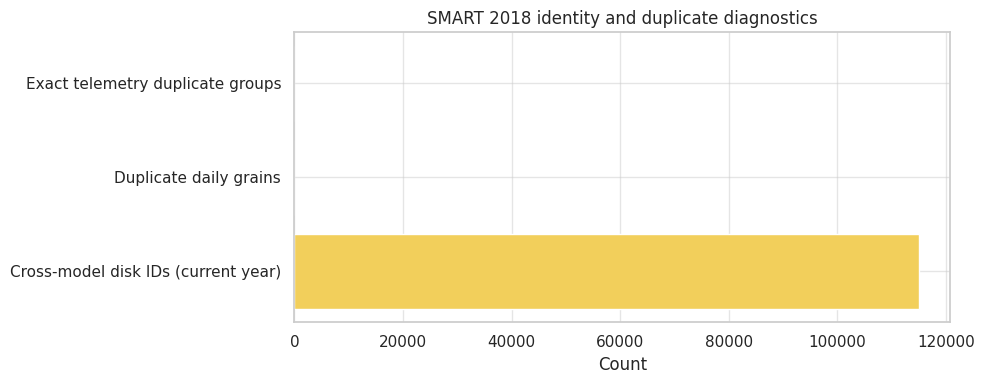

In [65]:
duplicate_analysis_summary = pd.DataFrame([
    {
        "CATEGORY": "Cross-model disk IDs (current year)",
        "COUNT": int(disk_identity_summary.iloc[0]["CROSS_MODEL_DISK_IDS"]),
    },
    {
        "CATEGORY": "Duplicate daily grains",
        "COUNT": int(daily_duplicate_summary.iloc[0]["DUPLICATE_DAILY_GRAINS"]),
    },
    {
        "CATEGORY": "Exact telemetry duplicate groups",
        "COUNT": int(
            exact_telemetry_duplicate_summary.iloc[0]["EXACT_DUPLICATE_GROUPS"]
        ),
    },
])
display(duplicate_analysis_summary)

_, axis = plt.subplots(figsize=(10, 4))
axis.barh(
    duplicate_analysis_summary["CATEGORY"],
    duplicate_analysis_summary["COUNT"],
    color=["#f2cf5b", "#4c78a8", "#d62728"],
)
axis.set_title("SMART 2018 identity and duplicate diagnostics")
axis.set_xlabel("Count")
plt.tight_layout()
plt.show()


## 5. Session cleanup

Stop the Spark session when the notebook analysis is complete. This releases
the local Spark driver; Snowflake warehouse suspension remains governed by the
warehouse's auto-suspend configuration.


In [66]:
spark.stop()

26/09/30 13:17:44 WARN SparkConnectorContext$: Finish cancelling all queries for local-1790771589591
